# Data Preprocessing
The dataset can be found at: https://www.kaggle.com/datasets/graphquest/restaurant-menu-items

## Load the data
Once you loaded the data from the link above, unzip it and place it in the same directory as this ipynb file.

In [181]:
import pandas as pd
import seaborn as sns
df = pd.read_csv("restaurantmenuchanges.csv", on_bad_lines="skip")

## EDA

### Find out data types and meaning of data features

In [182]:
df.shape

(4976, 19)

There are 4,976 records of data

In [183]:
df.head()

,createdOn,changeOperation,market,city,menuItemName,menuItemDescription,menuItemCurrentPrice,menuItemPreviousPrice,menuItemImageUrl,menuItemCategory,menuItemAverageRating,menuItemRatingCount,restaurantName,restaurantDescription,restaurantAddress,restaurantImageUrl,restaurantPriceRange,restaurantLatitude,restaurantLongitude
0,2022-10-27 23:07:19.0000000,Create,"Houston, TX",Houston,1% Low Fat Milk (110 Cals),"As delicious as our sandwiches are, they are e...",$2.19,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,Drinks,4.57420492172241,566,Subway,"Sandwiches, Salads, Dessert, Snacks","2003 Pease St, Houston, TX 77003, USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$,29.746686,-95.359915
1,2022-10-27 23:07:26.0000000,Delete,"Houston, TX",Houston,10-Piece Boneless Wing Meal,Served with fries and a drink.,$14.19,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,Boneless Wings,4.42056798934937,6194,American Deli,"Deli, Takeout, Gyro, Chicken, Burgers, Fast Fo...","6120 Scott St, Houston, TX 77021, USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$,29.700012,-95.360017
2,2022-10-27 23:07:26.0000000,Delete,"Houston, TX",Houston,8-Piece Boneless Wing Meal,Served with fries and a drink.,$12.99,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,Boneless Wings,4.42056798934937,6194,American Deli,"Deli, Takeout, Gyro, Chicken, Burgers, Fast Fo...","6120 Scott St, Houston, TX 77021, USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$,29.700012,-95.360017
3,2022-10-27 23:07:33.0000000,Delete,"Houston, TX",Houston,LUNCH DUET,Select two of these Benihana favorites:Beef* J...,$24.10,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,LUNCH ENTRÉES,4.35029411315918,2378,Benihana,"Chicken, Steak, Hibachi, Asian Food, Family Me...","1318 Louisiana St, Houston, TX, 77002 USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$$,29.756087,-95.369744
4,2022-10-27 23:07:33.0000000,Delete,"Houston, TX",Houston,FILET MIGNON,Tenderloin* and mushrooms lightly seasoned and...,$24.40,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,LUNCH ENTRÉES,4.35029411315918,2378,Benihana,"Chicken, Steak, Hibachi, Asian Food, Family Me...","1318 Louisiana St, Houston, TX, 77002 USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$$,29.756087,-95.369744


In [184]:
df.dtypes

createdOn                    str
changeOperation              str
market                       str
city                         str
menuItemName                 str
menuItemDescription          str
menuItemCurrentPrice         str
menuItemPreviousPrice        str
menuItemImageUrl             str
menuItemCategory             str
menuItemAverageRating        str
menuItemRatingCount          str
restaurantName               str
restaurantDescription        str
restaurantAddress            str
restaurantImageUrl           str
restaurantPriceRange         str
restaurantLatitude       float64
restaurantLongitude      float64
dtype: object

menuItemCurrentPrice, menuItemAverageRating, menuItemPreviousPrice and menuItemRatingCount are actually numerical data.

Convert menuItemCurrentPrice, menuItemAverageRating,menuItemPreviousPrice and menuItemRatingCount to float.

In [185]:
df['menuItemCurrentPrice'] = (
    df['menuItemCurrentPrice']
    .str.replace('$', '', regex=False)
    .astype(float)
)

In [186]:
df["menuItemAverageRating"] = pd.to_numeric(
    df["menuItemAverageRating"],
    errors="coerce"
)

In [187]:
df["menuItemRatingCount"] = pd.to_numeric(
    df["menuItemRatingCount"],
    errors="coerce"
)

In [188]:
df['menuItemPreviousPrice'] = (
    df['menuItemPreviousPrice']
    .str.replace('$', '', regex=False)
    .astype(float)
)

createdOn also should be datetime.

In [189]:
df['createdOn'] = pd.to_datetime(df['createdOn'])

In [190]:
df.dtypes

createdOn                datetime64[ns]
changeOperation                     str
market                              str
city                                str
menuItemName                        str
menuItemDescription                 str
menuItemCurrentPrice            float64
menuItemPreviousPrice           float64
menuItemImageUrl                    str
menuItemCategory                    str
menuItemAverageRating           float64
menuItemRatingCount             float64
restaurantName                      str
restaurantDescription               str
restaurantAddress                   str
restaurantImageUrl                  str
restaurantPriceRange                str
restaurantLatitude              float64
restaurantLongitude             float64
dtype: object

In [191]:
df.restaurantName.unique()

<ArrowStringArray>
[                           'Subway',                     'American Deli',
                          'Benihana',                        'Pho Saigon',
                  'Sticky's Chicken',                           'Izakaya',
                           'BunSlut',                          'Pho Binh',
                    'Dripped Birria',                          'B&T Cafe',
 ...
                         'JuiceWell',              'Cosmo Food With Mood',
                 'Cheaters Creamery',                         'Collina's',
               'B’s African Kitchen', 'Cowboys  & Indians Tex-In Kitchen',
                     'Thrive Juices',                    'The Burger Den',
                              'Wild',                 'The Chocolate Bar']
Length: 272, dtype: str

In [192]:
df.menuItemName.unique()

<ArrowStringArray>
[      '1% Low Fat Milk (110 Cals)',      '10-Piece Boneless Wing Meal',
       '8-Piece Boneless Wing Meal',                       'LUNCH DUET',
                     'FILET MIGNON',                    'HIBACHI STEAK',
            'SPICY HIBACHI CHICKEN',                  'HIBACHI CHICKEN',
                   'HIBACHI SHRIMP',                    'BEEF JULIENNE',
 ...
                   'Marinara Combo',                        'Aunt Etta',
             'Double Stuffed Oreos',                          'Twinkie',
              'Caramel Pretzel Rod',                 'Coconut Haystack',
                           'Toffee',              'Texas Frito Brittle',
                          'Almonds', 'Cowgirl Cotton Candy Pint (16oz)']
Length: 3589, dtype: str

But only 3,589 unique menus. This means that there are duplicate food menus.

In [193]:
mask = df.duplicated(subset=['menuItemName', 'restaurantName'], keep=False)

# 3. Filter the DataFrame to show only the matching rows
matching_pairs = df[mask].sort_values(by=['restaurantName', 'menuItemName'])

print("Rows with matching menuItemName and restaurantName:")
matching_pairs

Rows with matching menuItemName and restaurantName:


,createdOn,changeOperation,market,city,menuItemName,menuItemDescription,menuItemCurrentPrice,menuItemPreviousPrice,menuItemImageUrl,menuItemCategory,menuItemAverageRating,menuItemRatingCount,restaurantName,restaurantDescription,restaurantAddress,restaurantImageUrl,restaurantPriceRange,restaurantLatitude,restaurantLongitude
412,2022-10-27 23:13:10,Update,"Houston, TX",Houston,77. Beef with Asparagus,NaN,13.95,14.95,NaN,Beef,4.668927,1770.0,888 Chinese Restaurant,"Wings, Soup, Chinese, Seafood, Spring Rolls, A...","2410 S Wayside Dr, Houston, TX 77023, USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$$,29.714339,-95.316234
2235,2022-10-30 15:21:32,Update,"Houston, TX",Houston,77. Beef with Asparagus,NaN,14.95,13.95,NaN,Beef,4.668927,1770.0,888 Chinese Restaurant,"Wings, Soup, Chinese, Seafood, Spring Rolls, A...","2410 S Wayside Dr, Houston, TX 77023, USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$$,29.714339,-95.316234
1,2022-10-27 23:07:26,Delete,"Houston, TX",Houston,10-Piece Boneless Wing Meal,Served with fries and a drink.,14.19,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,Boneless Wings,4.420568,6194.0,American Deli,"Deli, Takeout, Gyro, Chicken, Burgers, Fast Fo...","6120 Scott St, Houston, TX 77021, USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$,29.700012,-95.360017
2004,2022-10-30 15:10:21,Create,"Houston, TX",Houston,10-Piece Boneless Wing Meal,Served with fries and a drink.,14.19,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,Boneless Wings,4.420568,6194.0,American Deli,"Deli, Takeout, Gyro, Chicken, Burgers, Fast Fo...","6120 Scott St, Houston, TX 77021, USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$,29.700012,-95.360017
2,2022-10-27 23:07:26,Delete,"Houston, TX",Houston,8-Piece Boneless Wing Meal,Served with fries and a drink.,12.99,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,Boneless Wings,4.420568,6194.0,American Deli,"Deli, Takeout, Gyro, Chicken, Burgers, Fast Fo...","6120 Scott St, Houston, TX 77021, USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$,29.700012,-95.360017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4829,2022-11-07 21:20:26,Delete,"Houston, TX",Houston,Banana Chia Pudding,Chia seeds soaked overnight in oat milk and sw...,6.50,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,Desserts,4.147009,585.0,ginger bowls (Healthy Asian Bowls),"Asian, Chinese, Bowls, Healthy, Vegetarian, Gl...","2616 Blodgett St, Houston, TX 77004, USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$$,29.722689,-95.370483
2292,2022-10-30 15:27:59,Create,"Houston, TX",Houston,Banana Chia Pudding,Chia seeds soaked overnight in oat milk and sw...,6.50,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,Desserts,4.331633,196.0,lulubowls (Hawaiian-Inspired Bowls),Hawaiian-inspired bowls concept.,"Boo-ya Bowls Houston, 2616 Blodgett St Unit K2...",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$$,29.722689,-95.370483
4973,2022-11-07 21:21:02,Delete,"Houston, TX",Houston,Banana Chia Pudding,Chia seeds soaked overnight in oat milk and sw...,6.50,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,Desserts,4.338384,198.0,lulubowls (Hawaiian-Inspired Bowls),Hawaiian-inspired bowls concept.,"Boo-ya Bowls Houston, 2616 Blodgett St Unit K2...",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,$$,29.722689,-95.370483
2025,2022-10-30 15:11:23,Create,"Houston, TX",Houston,Banana Chia Pudding,Chia seeds soaked overnight in oat milk and sw...,6.00,NaN,https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,Desserts,4.494005,2502.0,moonbowls - Healthy Korean Bowls,Korean Restaurant,"2616 Blodgett St, Houston, TX 77004, USA",https://img.cdn4dd.com/cdn-cgi/image/fit=conta...,NaN,29.722689,-95.370483


In [194]:
df.market.unique()

<ArrowStringArray>
['Houston, TX']
Length: 1, dtype: str

In [195]:
df.city.unique()

<ArrowStringArray>
['Houston']
Length: 1, dtype: str

From this, we can clearly see that there's only one city in the entire dataset.

### Find out missing values

In [196]:
df.isnull().sum()

createdOn                   0
changeOperation             0
market                      0
city                        0
menuItemName                0
menuItemDescription      1498
menuItemCurrentPrice        0
menuItemPreviousPrice    3021
menuItemImageUrl         2257
menuItemCategory            0
menuItemAverageRating       1
menuItemRatingCount         1
restaurantName              0
restaurantDescription       0
restaurantAddress           0
restaurantImageUrl        226
restaurantPriceRange       74
restaurantLatitude          1
restaurantLongitude         1
dtype: int64

### Find out distributions and range of values

In [197]:
df.describe()

,createdOn,menuItemCurrentPrice,menuItemPreviousPrice,menuItemAverageRating,menuItemRatingCount,restaurantLatitude,restaurantLongitude
count,4976,4976.000000,1955.000000,4975.000000,4975.000000,4975.000000,4975.000000
mean,2022-11-03 01:43:08.727291136,11.694266,10.760527,4.383872,2309.946131,29.752471,-95.387014
min,2022-10-27 23:07:19,0.150000,0.690000,0.000000,0.000000,29.695966,-95.443167
25%,2022-10-30 15:03:20,5.000000,4.990000,4.390255,97.000000,29.738020,-95.409316
50%,2022-10-30 15:44:06,8.990000,9.140000,4.650694,718.000000,29.750556,-95.382361
75%,2022-11-07 21:14:40,14.950000,14.000000,4.753402,3601.000000,29.763545,-95.370663
max,2022-11-07 21:21:03,375.000000,155.990000,5.000000,25777.000000,29.825951,-95.301327
std,NaN,14.012551,9.127910,0.930128,3117.036871,0.022496,0.024071


<Axes: ylabel='Count'>

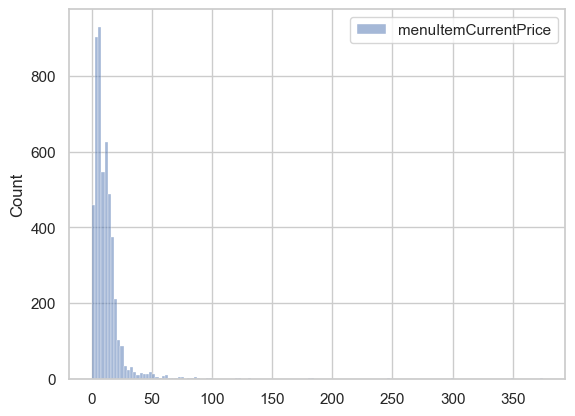

In [198]:
sns.histplot(df[["menuItemCurrentPrice"]])


<Axes: ylabel='Count'>

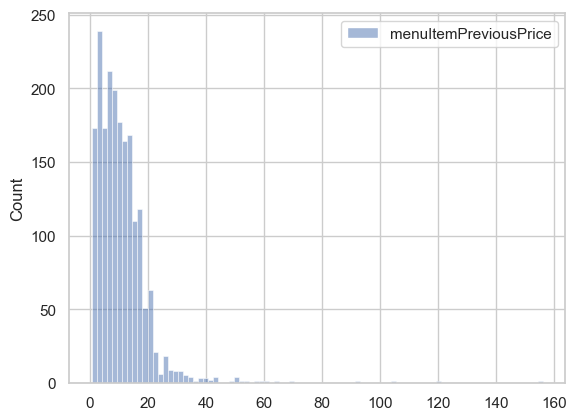

In [199]:
sns.histplot(df[["menuItemPreviousPrice"]])


<Axes: ylabel='Count'>

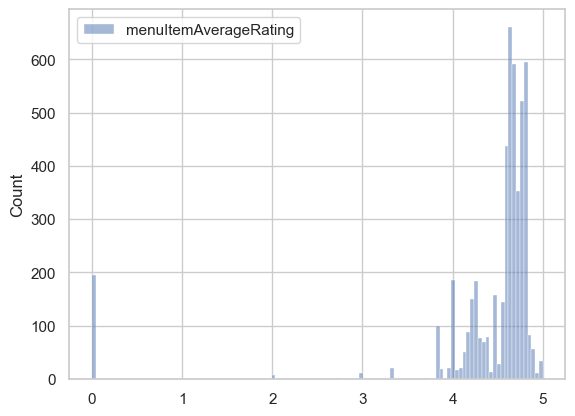

In [200]:
sns.histplot(df[["menuItemAverageRating"]])


<Axes: ylabel='Count'>

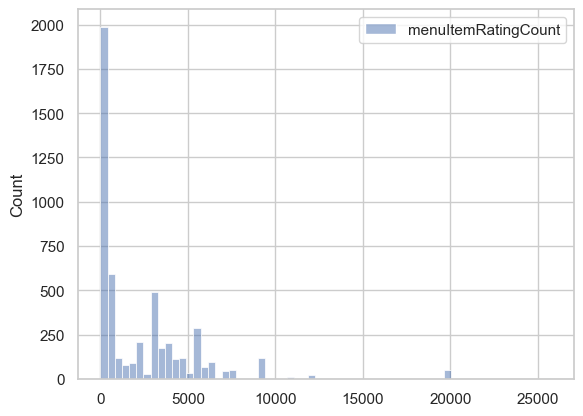

In [201]:
sns.histplot(df[["menuItemRatingCount"]])

<Axes: ylabel='Count'>

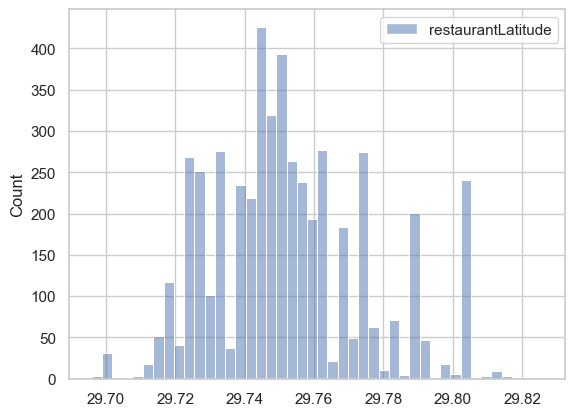

In [202]:
sns.histplot(df[["restaurantLatitude"]])

<Axes: ylabel='Count'>

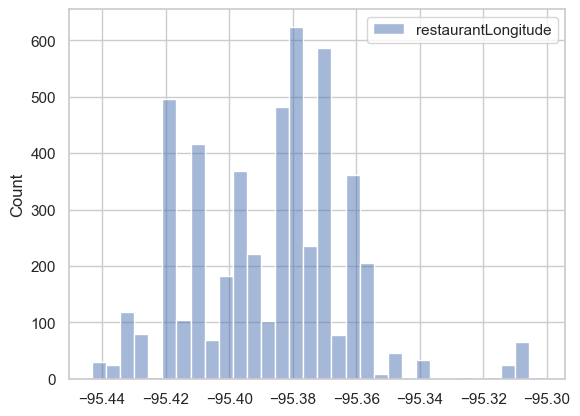

In [203]:
sns.histplot(df[["restaurantLongitude"]])

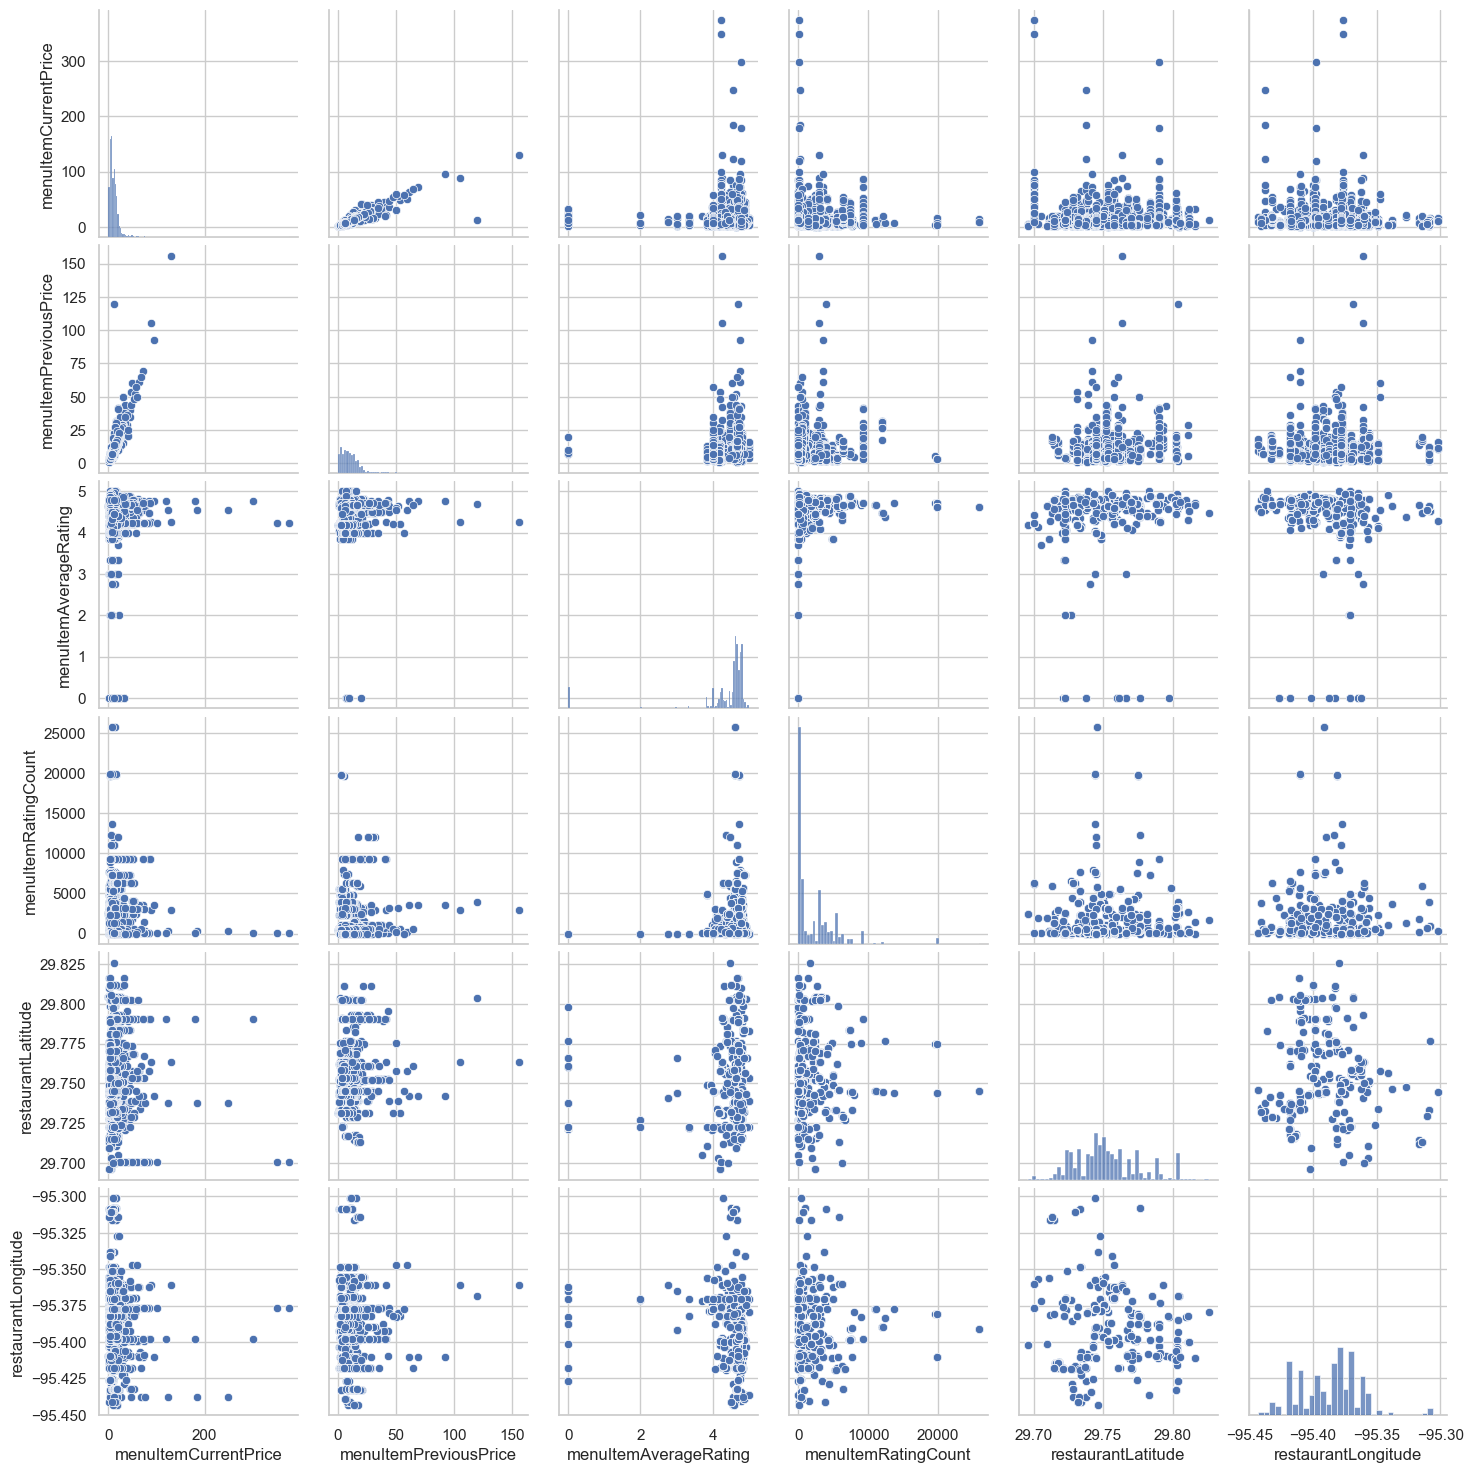

In [204]:
import seaborn as sns
sns.pairplot(df)

## Data Preprocessing

### Drop unused attributes.

- changeOperation (since this feature only tell us about which CRUD operation has taken place).
- city (since it’s the same as market, which only covers Houston, Texas)
- menuItemPreviousPrice
- menuItemImageUrl (since having LLM analyze images take a lot of time and compute power, both of which we don’t have)
- menuItemAverageRating (menu rating is out of scope of this project)
- menuItemRatingCount
- restaurantImageUrl
- restaurantPriceRange

In [205]:
df2 = df.drop(columns=['changeOperation', 'city', 'menuItemPreviousPrice', 'menuItemImageUrl', 'menuItemAverageRating', 'menuItemRatingCount', 'restaurantImageUrl', 'restaurantPriceRange'])

In [206]:
df2.shape

(4976, 11)

### Handle Missing Values

In [207]:
df2.isnull().sum()

createdOn                   0
market                      0
menuItemName                0
menuItemDescription      1498
menuItemCurrentPrice        0
menuItemCategory            0
restaurantName              0
restaurantDescription       0
restaurantAddress           0
restaurantLatitude          1
restaurantLongitude         1
dtype: int64

Fill restaurantLatitude and restaurantLongitude with median data.

In [208]:
df2[['restaurantLatitude', 'restaurantLongitude']] = (
    df2[['restaurantLatitude', 'restaurantLongitude']]
    .fillna(
        df2[['restaurantLatitude', 'restaurantLongitude']].median()
    )
)

For the menuItemDescription, we can fill the null value with empty string.

In [209]:
df2['menuItemDescription'] = df2['menuItemDescription'].fillna("")

In [210]:
df2.isnull().sum()

createdOn                0
market                   0
menuItemName             0
menuItemDescription      0
menuItemCurrentPrice     0
menuItemCategory         0
restaurantName           0
restaurantDescription    0
restaurantAddress        0
restaurantLatitude       0
restaurantLongitude      0
dtype: int64

Now, we can remove duplicate menus. First, we will sort by createdOn

In [211]:
df2 = df2.sort_values(by='createdOn')

Then, keep only the last value.

In [212]:
df2 = df2.drop_duplicates(subset=['menuItemName', 'restaurantName'], keep='last')

In [213]:
df2.dtypes

createdOn                datetime64[ns]
market                              str
menuItemName                        str
menuItemDescription                 str
menuItemCurrentPrice            float64
menuItemCategory                    str
restaurantName                      str
restaurantDescription               str
restaurantAddress                   str
restaurantLatitude              float64
restaurantLongitude             float64
dtype: object

Rename `menuItemCurrentPrice` to `price` since
1. We don't have menuItemPreviousPrice anymore
2. It's shorter to type later

In [214]:
df2 = df2.rename(columns={"menuItemCurrentPrice": "price"})
df2.columns

Index(['createdOn', 'market', 'menuItemName', 'menuItemDescription', 'price',
       'menuItemCategory', 'restaurantName', 'restaurantDescription',
       'restaurantAddress', 'restaurantLatitude', 'restaurantLongitude'],
      dtype='str')

## Save the prepared data

In [215]:
df2.to_csv("restaurant_menu_preprocessed.csv", index=False)